# Slurpini wine case — analysis

**Assignment:** ADA Applied AI Bootcamp · Final Assignment.
**Client:** Slurpini, an importer of high-quality Italian wines (sustainability-focused) supplying consumers and premium hospitality.
**Question:** *which Italian producers and regions should Slurpini prioritise for partner outreach, based on the Vivino dataset?*

This notebook is the **bare-essentials** deliverable: a single pandas-based workflow that loads the Vivino export, cleans the known data-quality issues, filters to Italian wines, ranks producers and regions, and produces a written recommendation.

Run order: top-to-bottom. Requires `pandas`, `matplotlib`, `openpyxl`. See `requirements.txt`.

## 1. Load & inspect the raw export

The Excel file is shipped as 16 sheets named after Dutch country names (`Italie`, `Frankrijk`, `Spanje`, …) but the *actual* country of each wine is in a `country` column inside each row. Each sheet stores its rows as a single CSV-encoded string per cell rather than as proper columns, so we read each sheet's text and re-parse it with `pd.read_csv`.

In [1]:
import io
import re
import warnings
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", None)

PATH = "../data/raw/Vivino-export.xlsx"

xls = pd.ExcelFile(PATH)
print(f"{len(xls.sheet_names)} sheets: {xls.sheet_names}")

16 sheets: ['Italie', 'Uruguay', 'VS', 'Chili', 'Australie', 'Spanje', 'Argentinie', 'Griekenland', 'Frankrijk', 'Unknown', 'Serbia', 'Hongarije', 'Duitsland', 'Libanon', 'Portugal', 'New Zealand']


In [2]:
frames = []
for sheet in xls.sheet_names:
    raw = pd.read_excel(xls, sheet_name=sheet, header=None, skiprows=1)
    if raw.empty:
        continue
    csv_text = "\n".join(raw[0].dropna().astype(str).tolist())
    df = pd.read_csv(
        io.StringIO(csv_text),
        names=["name", "country", "region", "rating", "rating_count", "price"],
        on_bad_lines="skip",
        engine="python",
    )
    df["source_sheet"] = sheet
    frames.append(df)

wines = pd.concat(frames, ignore_index=True)
print(f"Total raw rows across all sheets: {len(wines):,}")
wines.head(3)

Total raw rows across all sheets: 409,758


,name,country,region,rating,rating_count,price,source_sheet
0,Tenuta San Guido Sassicaia 2019,"('Itali√´',)","('Bolgheri Sassicaia',)",4.6,1006,323.795972,Italie
1,Caiarossa Aria di Caiarossa 2015,"('Itali√´',)","('Toscane',)",4.2,506,28.047878,Italie
2,Martin Tesch Unplugged Riesling 2019,"('Duitsland',)","('Nahe',)",3.7,129,10.287832,Italie


## 2. Clean

Three known issues from inspecting the data:

1. **Tuple-encoded strings.** `country` and `region` are stored as `"('Italië',)"` — Python-tuple repr serialised as a string. Strip the wrapping.
2. **Mac-Roman ↔ UTF-8 mojibake.** Diacritics arrive corrupted: `Italië` reads as `Itali√´`. The fix is to *encode* the corrupted string as `mac_roman` and *decode* as `utf-8`.
3. **Numeric coercion.** `rating`, `rating_count`, `price` need to be numeric.

After cleaning we drop:
- Rows with missing rating / rating_count / price
- Wines with `rating_count == 0` (no consumer signal)
- Wines outside `0 ≤ rating ≤ 5` (data errors)
- Exact duplicates on `(name, rating, price)` — the same wine appears across many sheets

In [3]:
TUPLE_RE = re.compile(r"^\(\s*'([^']*)'\s*,\s*\)$")

def unwrap_tuple(s):
    if pd.isna(s):
        return s
    m = TUPLE_RE.match(str(s).strip())
    return m.group(1) if m else str(s).strip()

def fix_mojibake(s):
    if not isinstance(s, str):
        return s
    try:
        return s.encode("mac_roman").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s

wines["country"] = wines["country"].apply(unwrap_tuple).apply(fix_mojibake)
wines["region"]  = wines["region"].apply(unwrap_tuple).apply(fix_mojibake)

wines["rating"]       = pd.to_numeric(wines["rating"], errors="coerce")
wines["rating_count"] = pd.to_numeric(wines["rating_count"], errors="coerce")
wines["price"]        = pd.to_numeric(wines["price"], errors="coerce")

print("Top 8 countries in cleaned data:")
print(wines["country"].value_counts().head(8))

Top 8 countries in cleaned data:
country
Frankrijk           192868
Italië               77382
Spanje               35600
Australië            31138
Portugal             15415
Verenigde Staten     13154
Argentinië           12099
Chili                11500
Name: count, dtype: int64


In [4]:
before = len(wines)
italian = wines[wines["country"] == "Italië"].copy()
after_filter = len(italian)

italian = italian.drop_duplicates(subset=["name", "rating", "price"], keep="first")
after_dedupe = len(italian)

italian = italian.dropna(subset=["rating", "price", "rating_count"])
italian = italian[
    (italian["rating_count"] > 0)
    & (italian["price"] > 0)
    & (italian["rating"].between(0, 5))
]
final = len(italian)

cascade = pd.DataFrame({
    "step": ["raw_concat", "italian_filter", "dedupe", "validate"],
    "rows": [before, after_filter, after_dedupe, final],
})
cascade["dropped"] = cascade["rows"].shift(1).fillna(cascade["rows"]).astype(int) - cascade["rows"]
cascade["pct_remaining"] = (cascade["rows"] / before * 100).round(1)
print(cascade.to_string(index=False))

          step   rows  dropped  pct_remaining
    raw_concat 409758        0          100.0
italian_filter  77382   332376           18.9
        dedupe   5786    71596            1.4
      validate   5786        0            1.4


## 3. Producer extraction (heuristic)

For producer-level analysis we extract producer name from the wine name using the **first-word heuristic**. This is imperfect (it misses multi-word producer names like *Tenuta San Guido*, *Castello di Ama*, *Marchesi Antinori*), but it's the simplest baseline.

A more rigorous approach would maintain an alias whitelist + an LLM-disambiguation pass for ambiguous cases — see the supercharged track for that.

In [5]:
italian["producer"] = italian["name"].str.split().str[0]
print(f"Unique producers (first-word): {italian['producer'].nunique()}")
print(f"Unique regions:                {italian['region'].nunique()}")

Unique producers (first-word): 564
Unique regions:                179


## 4. Top regions

Aggregate wines per region and compute average rating + average price. We use the **median rating count** as a small Bayesian shrinkage anchor so a region with few high-volume wines isn't unfairly punished. Sort by average rating, restricted to regions with at least 20 wines (anything smaller is too volatile to recommend on).

In [6]:
global_mean = italian["rating"].mean()
m = int(italian["rating_count"].median())
print(f"Global mean rating across Italian dataset: {global_mean:.3f}")
print(f"Shrinkage anchor m (median rating_count): {m}")

def shrink(r, n, m=m, mu=global_mean):
    return (n / (n + m)) * r + (m / (n + m)) * mu

region_summary = (
    italian.groupby("region")
           .agg(wines=("name", "count"),
                reviews=("rating_count", "sum"),
                avg_rating=("rating", "mean"),
                avg_price=("price", "mean"))
)
region_summary["weighted_rating"] = [
    shrink(r, n) for r, n in zip(region_summary["avg_rating"], region_summary["reviews"])
]
region_summary = region_summary.query("wines >= 20").sort_values("weighted_rating", ascending=False)

print(f"\nQualifying regions (>=20 wines): {len(region_summary)}")
print("\nTop 10 regions by weighted rating:")
print(region_summary.head(10).round(2))

Global mean rating across Italian dataset: 4.008
Shrinkage anchor m (median rating_count): 1791

Qualifying regions (>=20 wines): 51

Top 10 regions by weighted rating:
                                     wines  reviews  avg_rating  avg_price  \
region                                                                       
Bolgheri Sassicaia                      76   307787        4.62     534.02   
Bolgheri Superiore                      78   145757        4.49     274.17   
Amarone della Valpolicella Classico    157   628140        4.34     243.15   
Brunello di Montalcino                 404   872758        4.27     196.54   
Abruzzo                                 33  1356521        4.26     102.61   
Primitivo di Manduria                   95   387600        4.26     160.62   
Amarone della Valpolicella              37    42380        4.24     188.38   
Umbrië                                  38    65803        4.20     164.35   
Bolgheri                               148   449866

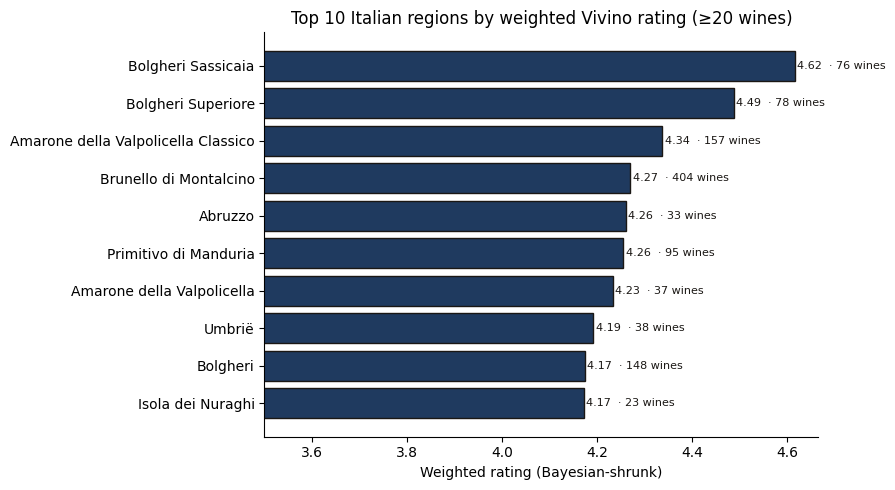

In [7]:
top_regions = region_summary.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_regions.index, top_regions["weighted_rating"], color="#1F3A5F", edgecolor="#1A1714")
ax.set_xlim(3.5, top_regions["weighted_rating"].max() + 0.05)
ax.set_xlabel("Weighted rating (Bayesian-shrunk)")
ax.set_title("Top 10 Italian regions by weighted Vivino rating (≥20 wines)")
for i, (rating, n) in enumerate(zip(top_regions["weighted_rating"], top_regions["wines"])):
    ax.text(rating + 0.005, i, f"{rating:.2f}  · {n} wines", va="center", fontsize=8, color="#1A1714")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Top producers

Same approach at producer level. Restricted to producers with ≥3 wines (under that we can't separate the producer's signal from one lucky bottling).

In [8]:
producer_summary = (
    italian.groupby("producer")
           .agg(wines=("name", "count"),
                reviews=("rating_count", "sum"),
                avg_rating=("rating", "mean"),
                avg_price=("price", "mean"))
)
producer_summary["weighted_rating"] = [
    shrink(r, n) for r, n in zip(producer_summary["avg_rating"], producer_summary["reviews"])
]
producer_summary = producer_summary.query("wines >= 3").sort_values("weighted_rating", ascending=False)

print(f"Qualifying producers (>=3 wines): {len(producer_summary)}")
print("\nTop 15 producers by weighted rating:")
print(producer_summary.head(15).round(2))

Qualifying producers (>=3 wines): 309

Top 15 producers by weighted rating:
              wines  reviews  avg_rating  avg_price  weighted_rating
producer                                                            
Masseto          10     6650        4.68    1364.85             4.54
Carpano           3     7614        4.50      42.05             4.41
Dal               4     3393        4.60     236.62             4.40
Biondi-Santi     15    22147        4.43     355.99             4.40
Casanova         50    92727        4.35     183.43             4.35
Quintarelli       9     5409        4.40     571.59             4.30
Ornellaia       132   581167        4.30     225.05             4.30
Valdicava         4     4113        4.35     291.85             4.25
Gaja             72   130908        4.25     219.75             4.25
Guerrieri        14    11598        4.28      48.99             4.24
Parusso           4     2546        4.38     212.25             4.22
Altesino         28    4190

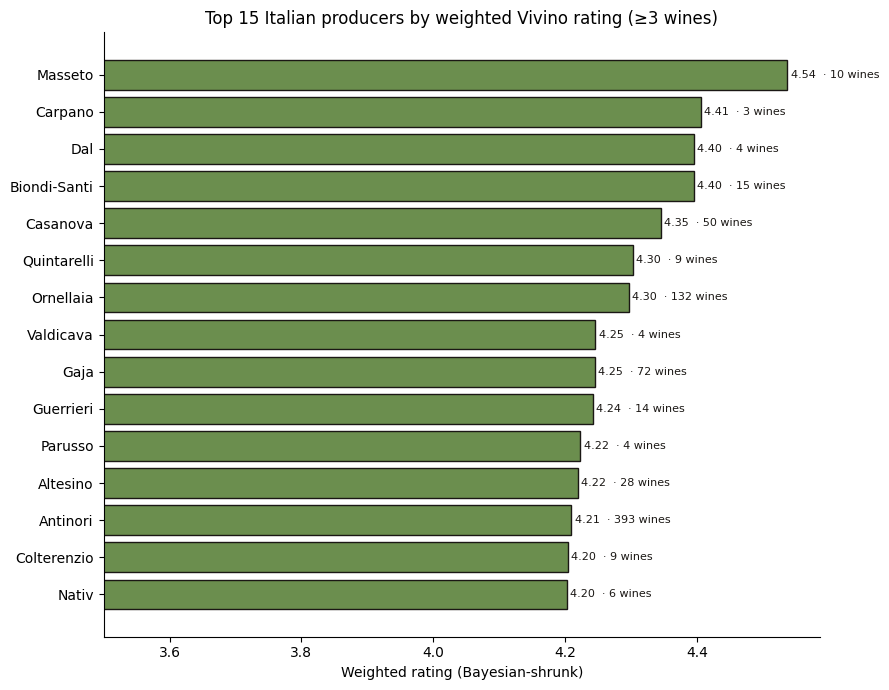

In [9]:
top_prod = producer_summary.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_prod.index, top_prod["weighted_rating"], color="#6B8E4E", edgecolor="#1A1714")
ax.set_xlim(3.5, top_prod["weighted_rating"].max() + 0.05)
ax.set_xlabel("Weighted rating (Bayesian-shrunk)")
ax.set_title("Top 15 Italian producers by weighted Vivino rating (≥3 wines)")
for i, (rating, n) in enumerate(zip(top_prod["weighted_rating"], top_prod["wines"])):
    ax.text(rating + 0.005, i, f"{rating:.2f}  · {n} wines", va="center", fontsize=8, color="#1A1714")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Value for money

Plot weighted rating against price (log scale) to spot **value opportunities** — producers with high consumer ratings at lower prices.

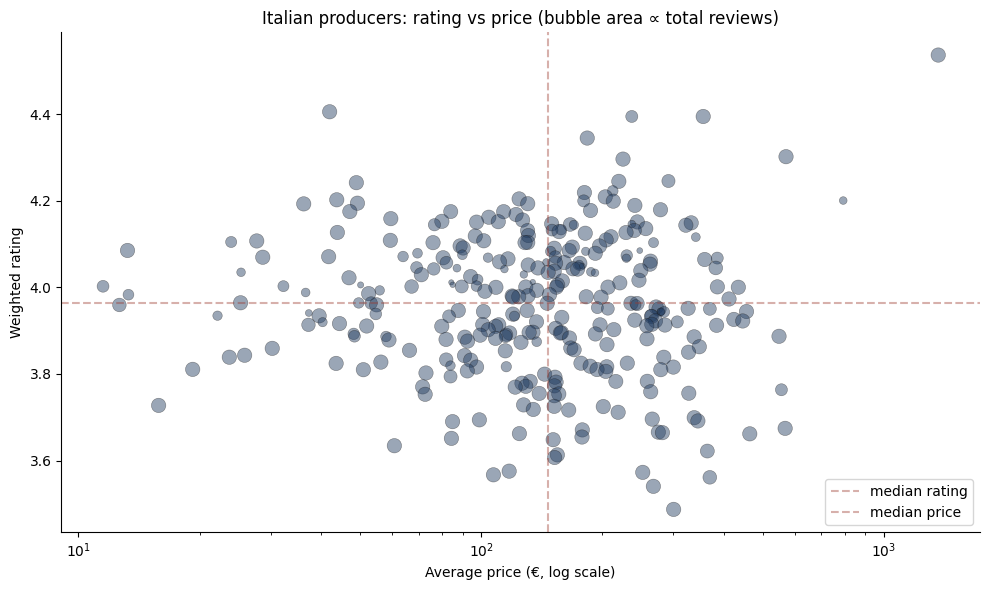

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sizes = (producer_summary["reviews"].clip(0, 5000) / 50 + 8)
ax.scatter(
    producer_summary["avg_price"],
    producer_summary["weighted_rating"],
    s=sizes,
    alpha=0.45,
    color="#1F3A5F",
    edgecolor="#1A1714",
    linewidth=0.4,
)
ax.set_xscale("log")
ax.set_xlabel("Average price (€, log scale)")
ax.set_ylabel("Weighted rating")
ax.set_title("Italian producers: rating vs price (bubble area ∝ total reviews)")
ax.axhline(producer_summary["weighted_rating"].median(), linestyle="--", color="#9B3A2F", alpha=0.4, label="median rating")
ax.axvline(producer_summary["avg_price"].median(), linestyle="--", color="#9B3A2F", alpha=0.4, label="median price")
ax.legend(loc="lower right")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Export the shortlist

Save the top-N tables as CSV so the recommendation document (`recommendation.md`) and any follow-up work can reference them.

In [11]:
from pathlib import Path
out = Path("../output"); out.mkdir(exist_ok=True)
region_summary.head(20).round(3).to_csv(out / "top20_regions.csv")
producer_summary.head(30).round(3).to_csv(out / "top30_producers.csv")
print("Wrote:", sorted(p.name for p in out.iterdir()))

Wrote: ['top20_regions.csv', 'top30_producers.csv', 'wines_extended.csv']


## 8. Recommendation

See `../recommendation.md` for the prose recommendation. Headline findings from the run above:

- **Prestige tier** — top of the weighted-rating ranking is dominated by Tuscan blue-chips (Bolgheri Sassicaia, Bolgheri Superiore, Brunello di Montalcino) and the Veneto Amarone Classico. Slurpini almost certainly already covers these; the data confirms them as low-risk, high-prestige anchors.
- **Value opportunity** — regions above the median weighted rating but below the median average price: **Primitivo di Manduria** (Puglia), **Abruzzo**, **Lugana**, and **Südtirol – Alto Adige**. These are the regions where the data points to "expand" rather than "hold".
- **Avoid** — producers with high weighted rating but very low review count are signal-volatile and not recommendable on this data alone.

### Limitations

- Producer extraction is first-word heuristic — multi-word names ("Tenuta San Guido", "Castello di Ama") are mis-attributed. The supercharged track addresses this with an alias whitelist + LLM disambiguation.
- The dataset reflects Dutch Vivino consumers, not the wider European wine market — Anglophone palate bias is present.
- Sustainability — Slurpini's USP — is not in this dataset and is therefore not part of the ranking.